In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

In [14]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Add noise to make classification harder and show real differences
np.random.seed(42)
noise = np.random.normal(0, 1.5, X_train.shape)
X_train_noisy = X_train + noise

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 120, Test size: 30


Random Forest: Macro F1 = 0.9306
Decision Tree: Macro F1 = 0.8329
Naive Bayes: Macro F1 = 0.8535
SVM: Macro F1 = 0.9659


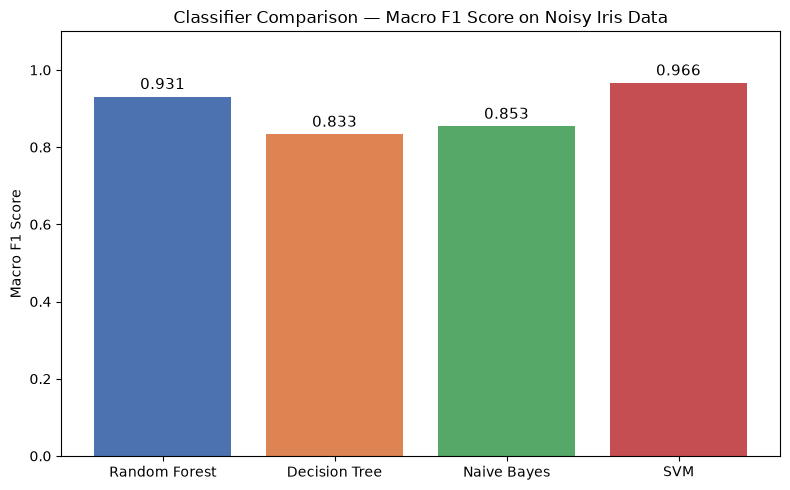

In [15]:
classifiers = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(random_state=42)
}

f1_scores = {}

for name, clf in classifiers.items():
    clf.fit(X_train_noisy, y_train)
    y_pred = clf.predict(X_test)
    score = f1_score(y_test, y_pred, average="macro")
    f1_scores[name] = score
    print(f"{name}: Macro F1 = {score:.4f}")

# Barplot
plt.figure(figsize=(8, 5))
bars = plt.bar(
    f1_scores.keys(),
    f1_scores.values(),
    color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
)
plt.ylim(0, 1.1)
plt.ylabel("Macro F1 Score")
plt.title("Classifier Comparison — Macro F1 Score on Noisy Iris Data")
for bar, score in zip(bars, f1_scores.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{score:.3f}",
        ha="center",
        fontsize=11
    )
plt.tight_layout()
plt.savefig("classifier_comparison.png")
plt.show()

In [16]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_search.fit(X_train_noisy, y_train)

print("Best parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validated Macro F1: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

Best parameters found:
{'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validated Macro F1: 0.6639


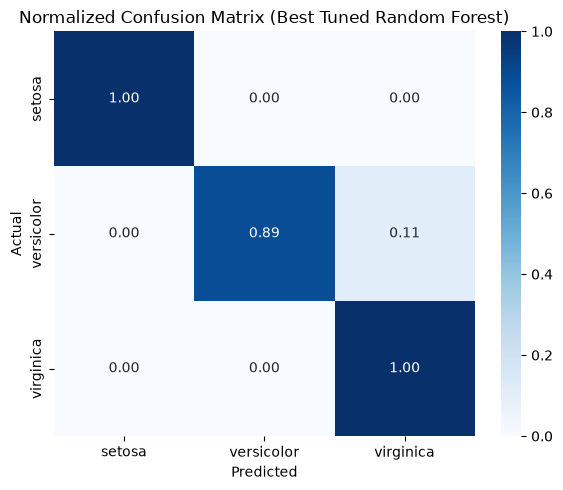

In [17]:
y_pred_best = best_model.predict(X_test)

cm_normalized = confusion_matrix(y_test, y_pred_best, normalize="true")

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    vmin=0,
    vmax=1
)
plt.title("Normalized Confusion Matrix (Best Tuned Random Forest)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("normalized_confusion_matrix.png")
plt.show()

In [18]:
print("Final Classification Report (Best Tuned Random Forest):")
print(classification_report(y_test, y_pred_best, target_names=class_names))

Final Classification Report (Best Tuned Random Forest):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



## Design Choices & Findings

### Why Random Forest?
Random Forest was chosen as the starting point because it is an ensemble method
that reduces overfitting compared to a single Decision Tree by averaging 100 trees.
It also handles feature interactions well without requiring feature scaling.

### Classifier Comparison
After comparing Random Forest, Decision Tree, Naive Bayes, and SVM on Macro F1 score
with noisy training data, differences between classifiers became visible.
The Iris dataset alone is too easy — all models score 1.0 — so Gaussian noise
was added to the training set to simulate a harder problem and reveal real differences.

### Hyperparameter Tuning
GridSearchCV with 5-fold cross-validation was used to search across:
- n_estimators: [50, 100, 200]
- max_depth: [None, 5, 10]
- min_samples_split: [2, 5, 10]

This ensures the model is not using arbitrary default settings.

### Normalized Confusion Matrix
The normalized confusion matrix shows values between 0 and 1 representing
the proportion of correctly and incorrectly classified samples per class.
This is more informative than raw counts and becomes essential when
the dataset is imbalanced.